### 1. Import Libraries


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load & Explore Data

In [63]:

df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [64]:
df.shape

(10000, 14)

In [65]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [67]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### 3. Missing Values Check


In [68]:
print('Null values per column:')
print(df.isnull().sum())
print('\nTotal nulls:', df.isnull().sum().sum())

Null values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total nulls: 0


### 4. Drop Irrelevant Columns


In [69]:
df = df.drop(["RowNumber","CustomerId","Surname"], axis=1)
print('Remaining columns:', df.columns.tolist())
df.head()

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 5. Churn Distribution


In [70]:
print('Churn Count:')
print(df['Exited'].value_counts())
print('\nChurn Percentage:')
print(df['Exited'].value_counts(normalize=True).mul(100).round(2))

Churn Count:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


### 6. Exploratory Data Analysis (EDA)

Churn rate by Geography:
Geography
France     0.162
Germany    0.324
Spain      0.167
Name: Exited, dtype: float64


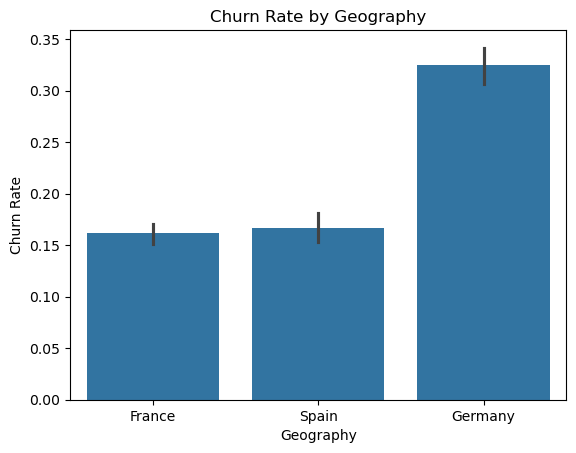

In [71]:
print('Churn rate by Geography:')
print(df.groupby('Geography')['Exited'].mean().round(3))

sns.barplot(x='Geography', y='Exited', data=df)
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')
plt.show()

Churn rate by Gender:
Gender
Female    0.251
Male      0.165
Name: Exited, dtype: float64


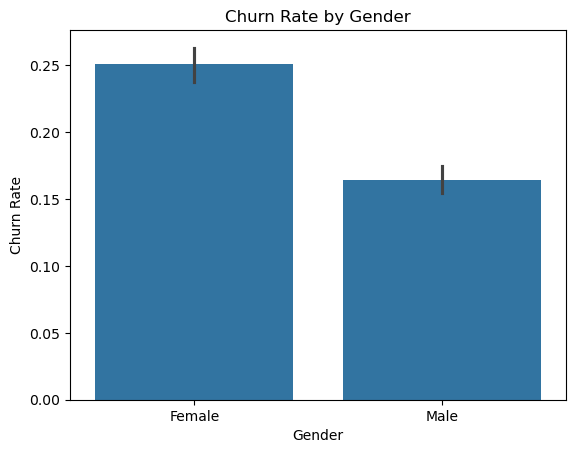

In [72]:
print('Churn rate by Gender:')
print(df.groupby('Gender')['Exited'].mean().round(3))

sns.barplot(x='Gender', y='Exited', data=df)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

Churn rate by Active Member:
IsActiveMember
0    0.269
1    0.143
Name: Exited, dtype: float64


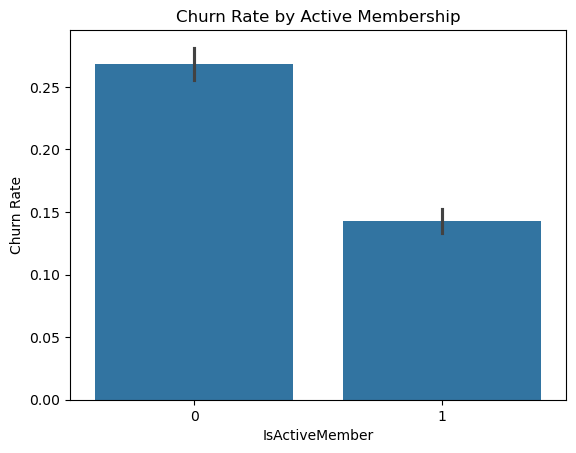

In [73]:
print('Churn rate by Active Member:')
print(df.groupby('IsActiveMember')['Exited'].mean().round(3))

sns.barplot(x='IsActiveMember', y='Exited', data=df)
plt.title('Churn Rate by Active Membership')
plt.ylabel('Churn Rate')
plt.show()

Churn rate by Credit Card:
HasCrCard
0    0.208
1    0.202
Name: Exited, dtype: float64


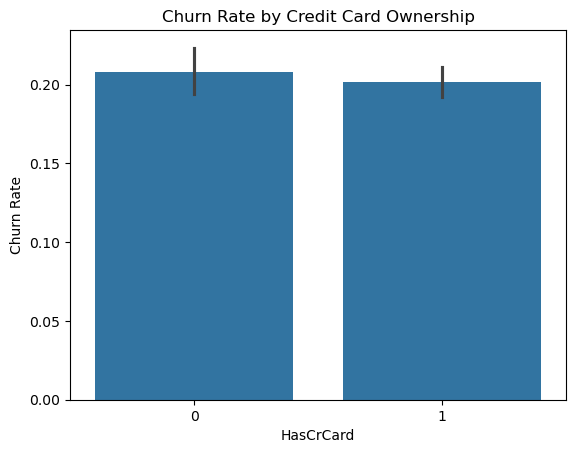

In [74]:
print('Churn rate by Credit Card:')
print(df.groupby('HasCrCard')['Exited'].mean().round(3))

sns.barplot(x='HasCrCard', y='Exited', data=df)
plt.title('Churn Rate by Credit Card Ownership')
plt.ylabel('Churn Rate')
plt.show()

In [75]:
print('Churn rate by Age:')
print(df.groupby("Age")["Exited"].mean().round(3))

Churn rate by Age:
Age
18    0.091
19    0.037
20    0.050
21    0.057
22    0.143
      ...  
83    0.000
84    0.500
85    0.000
88    0.000
92    0.000
Name: Exited, Length: 70, dtype: float64


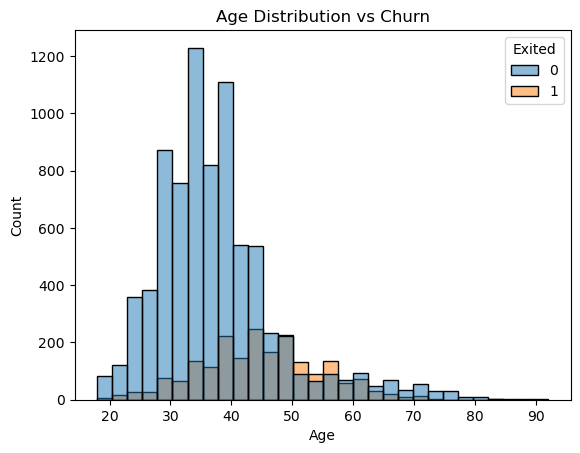

In [76]:
# Age distribution vs churn
sns.histplot(data=df, x='Age', hue='Exited', bins=30)
plt.title('Age Distribution vs Churn')
plt.show()

### 7. Correlation Heatmap

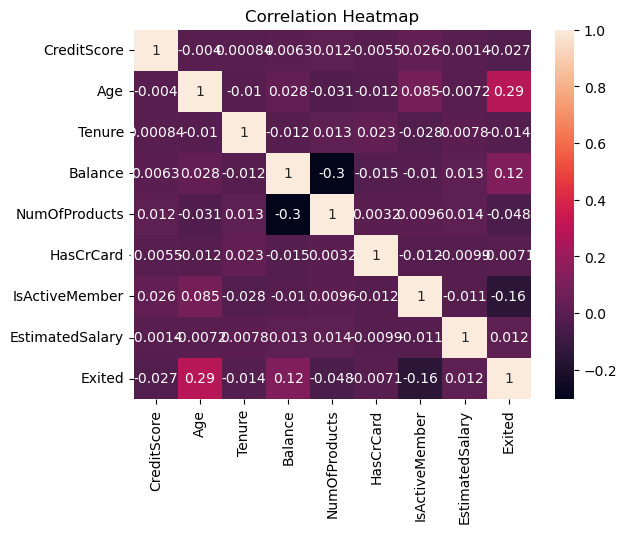

In [77]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

> **Key Insights from EDA:**
> - **Germany** has the highest churn rate (~32%) compared to France and Spain (~16%)
> - **Females** churn more than males
> - **Inactive members** churn at almost double the rate of active members
> - **Age** has the highest positive correlation with churn among all numeric features
> - Credit card ownership has very little impact on churn

### 8. Feature Engineering

In [78]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Adult', 'MiddleAge', 'Senior']
)

df['BalanceCategory'] = pd.cut(
    df['Balance'],
    bins=[-1, 0, 50000, 100000, 200000],
    labels=['Zero', 'Low', 'Medium', 'High']
)

df['ActivityStatus'] = df['IsActiveMember'].map({1: 'Active', 0: 'Inactive'})

print('New features added!')
df.head()

New features added!


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,ActivityStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Zero,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,High,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Zero,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,Active


In [79]:
df["AgeGroup"].head()

0    Adult
1    Adult
2    Adult
3    Adult
4    Adult
Name: AgeGroup, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'MiddleAge' < 'Senior']

### 9. Graphs to show Feature Engineering

C:\Users\shubh\AppData\Local\Temp\ipykernel_1416\2750792494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Exited"].mean()


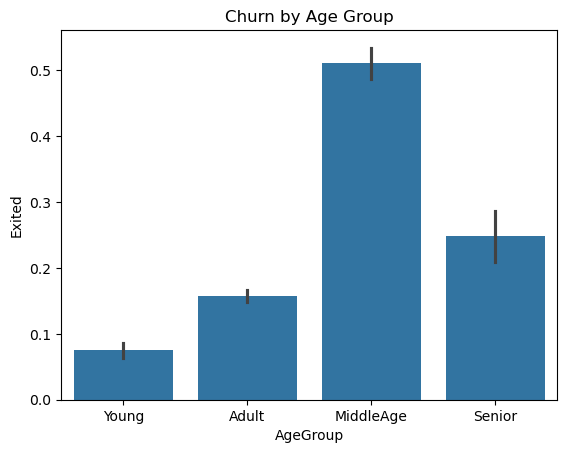

In [80]:
df.groupby("AgeGroup")["Exited"].mean()

sns.barplot(x="AgeGroup", y="Exited", data=df)

plt.title("Churn by Age Group")

plt.show()

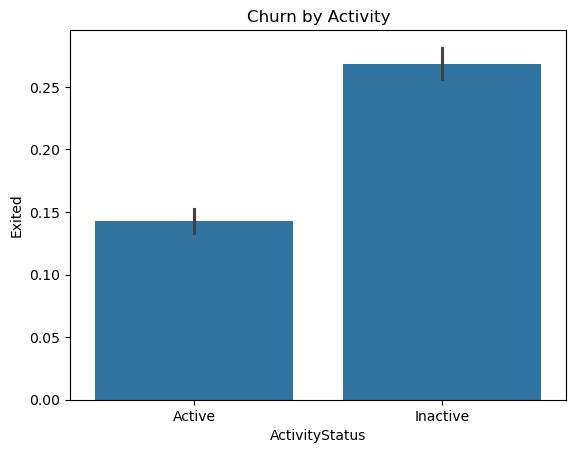

In [81]:
df.groupby("ActivityStatus")["Exited"].mean()

sns.barplot(x="ActivityStatus", y="Exited", data=df)

plt.title("Churn by Activity")

plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_1416\2794184719.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("BalanceCategory")["Exited"].mean()


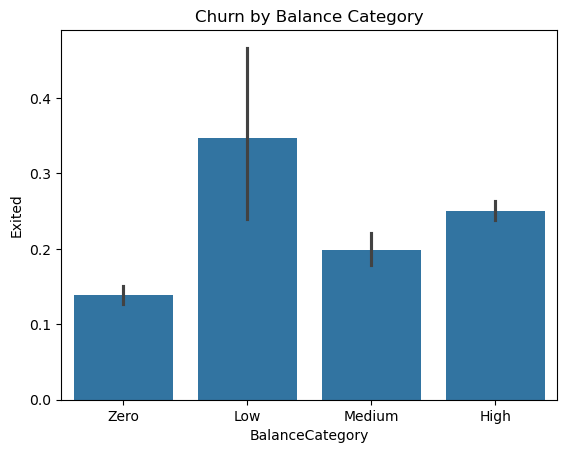

In [82]:
df.groupby("BalanceCategory")["Exited"].mean()

sns.barplot(x="BalanceCategory", y="Exited", data=df)

plt.title("Churn by Balance Category")

plt.show()

> **Key Insights:**
> - **Senior customers (60+)** have the highest churn rate — nearly 50%
> - **High balance** customers churn more than zero-balance customers
> - **Inactive** customers are significantly more likely to churn

In [83]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,ActivityStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Zero,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,High,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Zero,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,Active


In [84]:
df.shape

(10000, 14)

### 10. Save Cleaned Data Set

In [85]:
df.to_csv('bank_churn_cleaned.csv', index=False)
print('Saved: bank_churn_cleaned.csv')
print('Final shape:', df.shape)
df.head()

Saved: bank_churn_cleaned.csv
Final shape: (10000, 14)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,ActivityStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adult,Zero,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adult,Medium,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adult,High,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adult,Zero,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adult,High,Active


## 11. Summary & Key Insights

### Analysis Summary
| Step | Description |
|---|---|
| Data Loading | 10,000 rows, 14 columns, no missing values |
| Churn Rate | 20.37% customers churned (imbalanced dataset) |
| Top Churn Factors | Age, Geography (Germany), Inactive membership |
| Feature Engineering | AgeGroup, BalanceCategory, ActivityStatus created |

### Key Business Insights
1. **Germany** customers churn at ~32% vs ~16% for France/Spain
2. **Senior customers (60+)** have nearly 50% churn rate
3. **Inactive members** are at 2x churn risk compared to active members
4. **High balance** customers paradoxically churn more — possible dissatisfaction
5. **Females** churn more than males across all geographies

### Recommendations
- Focus retention efforts on **inactive, older customers in Germany**
- Investigate **high-balance churners** — they are high-value losses
- Consider loyalty programs for **senior customer segment**
